In [2]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, mean_absolute_error, accuracy_score
from xgboost import XGBClassifier, XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# ── Load from SQLite ─────────────────────────────────────
conn = sqlite3.connect('digital_lending.db')
df = pd.read_sql_query("SELECT * FROM loans", conn)
conn.close()

print(f"Loaded: {df.shape}")
print(df.head(2))

Loaded: (765140, 27)
   loan_amount  interest_rate  term_months   income    dti  credit_score  \
0       5000.0          10.65         36.0  24000.0  27.65         739.0   
1       2500.0          15.27         60.0  30000.0   1.00         744.0   

   employment_length home_ownership lending_medium  default  ...  \
0               10.0           RENT            P2P        0  ...   
1                0.0           RENT            P2P        1  ...   

   income_segment  risk_interaction  digital_onboarding  \
0             Low          5.760177                   1   
1          Middle          0.083331                   0   

   upi_transaction_count  mobile_credit_score first_time_borrower urban_flag  \
0                     43           615.905387                   0          1   
1                     44           658.523390                   1          1   

  risk_tier  expected_loss  loan_id  
0    Medium       0.000000        1  
1      High    1367.052951        2  

[2 rows x 2

In [3]:
from sklearn.cluster import KMeans

# ── Features ─────────────────────────────────────────────
features = [
    'loan_amount', 'interest_rate', 'term_months', 'income',
    'dti', 'credit_score', 'employment_length',
    'loan_to_income', 'monthly_burden', 'high_dti_flag',
    'long_term_flag', 'cost_of_credit', 'risk_interaction',
    'digital_onboarding', 'upi_transaction_count',
    'mobile_credit_score', 'first_time_borrower', 'urban_flag',
    'home_ownership_enc', 'lending_medium_enc',
    'loan_size_enc', 'credit_tier_enc', 'income_segment_enc'
]

# ── Encode if not already ─────────────────────────────────
if 'home_ownership_enc' not in df.columns:
    df['home_ownership_enc'] = df['home_ownership'].astype('category').cat.codes
if 'lending_medium_enc' not in df.columns:
    df['lending_medium_enc'] = df['lending_medium'].astype('category').cat.codes
if 'loan_size_enc' not in df.columns:
    df['loan_size_enc'] = df['loan_size'].map({'Micro':0,'Small':1,'Medium':2,'Large':3}).fillna(0)
if 'credit_tier_enc' not in df.columns:
    df['credit_tier_enc'] = df['credit_tier'].map({'Poor':0,'Fair':1,'Good':2,'Very Good':3,'Exceptional':4,'Unknown':-1}).fillna(-1)
if 'income_segment_enc' not in df.columns:
    df['income_segment_enc'] = df['income_segment'].map({'Low':0,'Middle':1,'Upper Middle':2,'High':3,'Unknown':-1}).fillna(-1)

X = df[features].copy()
y_default = df['default']
y_risk = df['risk_tier'].map({'Low':0,'Medium':1,'High':2})
y_loss = df['expected_loss']

# ── Sample for speed (765k is large) ─────────────────────
sample_idx = df.sample(100000, random_state=42).index
X_sample = X.loc[sample_idx]
y_default_sample = y_default.loc[sample_idx]
y_risk_sample = y_risk.loc[sample_idx]
y_loss_sample = y_loss.loc[sample_idx]

# ── Scale ─────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# ── Split ─────────────────────────────────────────────────
X_train, X_test, y_train_d, y_test_d = train_test_split(X_sample, y_default_sample, test_size=0.2, random_state=42)
_, _, y_train_r, y_test_r = train_test_split(X_sample, y_risk_sample, test_size=0.2, random_state=42)
_, _, y_train_l, y_test_l = train_test_split(X_sample, y_loss_sample, test_size=0.2, random_state=42)
X_train_s, X_test_s, _, _ = train_test_split(X_scaled, y_default_sample, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate in sample: {y_default_sample.mean():.3f}")

Train: (80000, 23), Test: (20000, 23)
Default rate in sample: 0.040


In [4]:
# ══════════════════════════════════════════════════════════
# TASK 1 — DEFAULT CLASSIFICATION
# ══════════════════════════════════════════════════════════
print("=" * 55)
print("TASK 1 — DEFAULT CLASSIFICATION")
print("=" * 55)

models_clf = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=42, n_jobs=-1,
        verbosity=0, scale_pos_weight=y_default_sample.value_counts()[0]/y_default_sample.value_counts()[1]
    ),
    'Logistic Reg': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    )
}

clf_results = {}
for name, model in models_clf.items():
    if name == 'Logistic Reg':
        model.fit(X_train_s, y_train_d)
        preds = model.predict(X_test_s)
    else:
        model.fit(X_train, y_train_d)
        preds = model.predict(X_test)
    acc = accuracy_score(y_test_d, preds)
    clf_results[name] = acc
    print(f"{name:20s} → Accuracy: {acc:.4f}")
    print(classification_report(y_test_d, preds, target_names=['No Default', 'Default']))

# ══════════════════════════════════════════════════════════
# TASK 2 — RISK TIER CLASSIFICATION
# ══════════════════════════════════════════════════════════
print("=" * 55)
print("TASK 2 — RISK TIER CLASSIFICATION")
print("=" * 55)

models_risk = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, verbosity=0
    ),
    'Logistic Reg': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    )
}

risk_results = {}
for name, model in models_risk.items():
    if name == 'Logistic Reg':
        model.fit(X_train_s, y_train_r)
        preds = model.predict(X_test_s)
    else:
        model.fit(X_train, y_train_r)
        preds = model.predict(X_test)
    acc = accuracy_score(y_test_r, preds)
    risk_results[name] = acc
    print(f"{name:20s} → Accuracy: {acc:.4f}")

# ══════════════════════════════════════════════════════════
# TASK 3 — EXPECTED LOSS REGRESSION
# ══════════════════════════════════════════════════════════
print("=" * 55)
print("TASK 3 — EXPECTED LOSS REGRESSION")
print("=" * 55)

models_reg = {
    'Random Forest': RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100, random_state=42, n_jobs=-1, verbosity=0
    )
}

reg_results = {}
for name, model in models_reg.items():
    model.fit(X_train, y_train_l)
    mae = mean_absolute_error(y_test_l, model.predict(X_test))
    reg_results[name] = mae
    print(f"{name:20s} → MAE: {mae:.4f}")

# ══════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"\n{'Model':<20} {'Default Acc':>12} {'Risk Acc':>10} {'Loss MAE':>10}")
print("-" * 55)
for name in ['Random Forest', 'XGBoost', 'Logistic Reg']:
    mae = reg_results.get(name, '-')
    mae_str = f"{mae:.4f}" if isinstance(mae, float) else mae
    print(f"{name:<20} {clf_results[name]:>12.4f} {risk_results[name]:>10.4f} {mae_str:>10}")

TASK 1 — DEFAULT CLASSIFICATION
Random Forest        → Accuracy: 0.9643
              precision    recall  f1-score   support

  No Default       0.97      1.00      0.98     19215
     Default       0.72      0.15      0.24       785

    accuracy                           0.96     20000
   macro avg       0.84      0.57      0.61     20000
weighted avg       0.96      0.96      0.95     20000

XGBoost              → Accuracy: 0.8854
              precision    recall  f1-score   support

  No Default       0.99      0.89      0.94     19215
     Default       0.21      0.68      0.32       785

    accuracy                           0.89     20000
   macro avg       0.60      0.79      0.63     20000
weighted avg       0.96      0.89      0.91     20000

Logistic Reg         → Accuracy: 0.8893
              precision    recall  f1-score   support

  No Default       0.98      0.90      0.94     19215
     Default       0.21      0.66      0.32       785

    accuracy                  

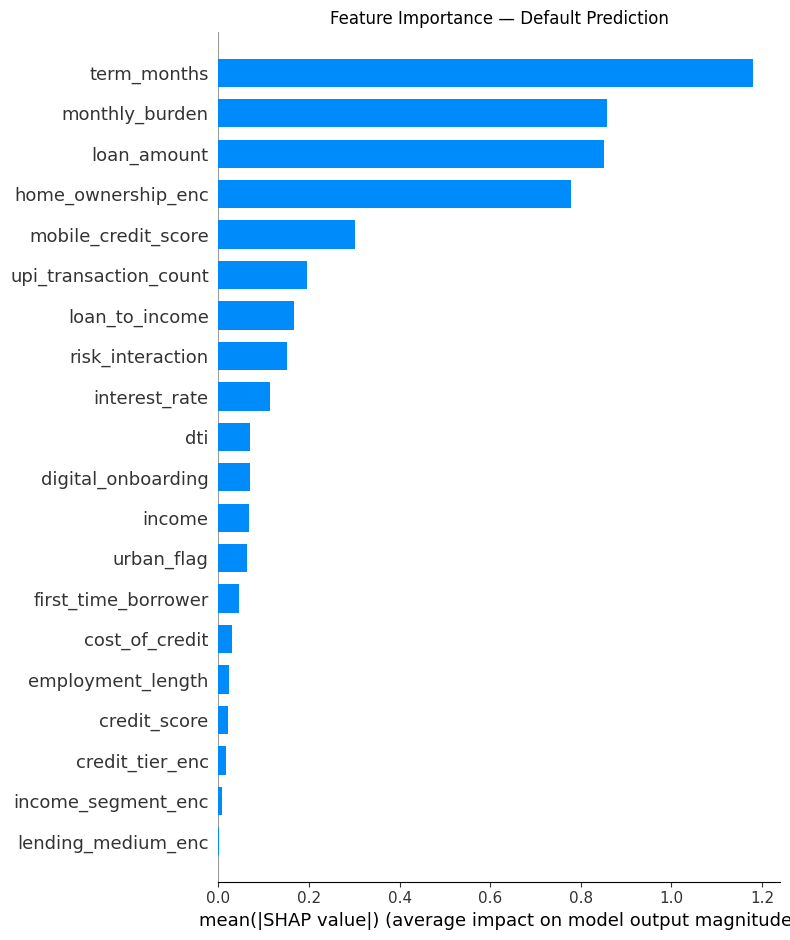

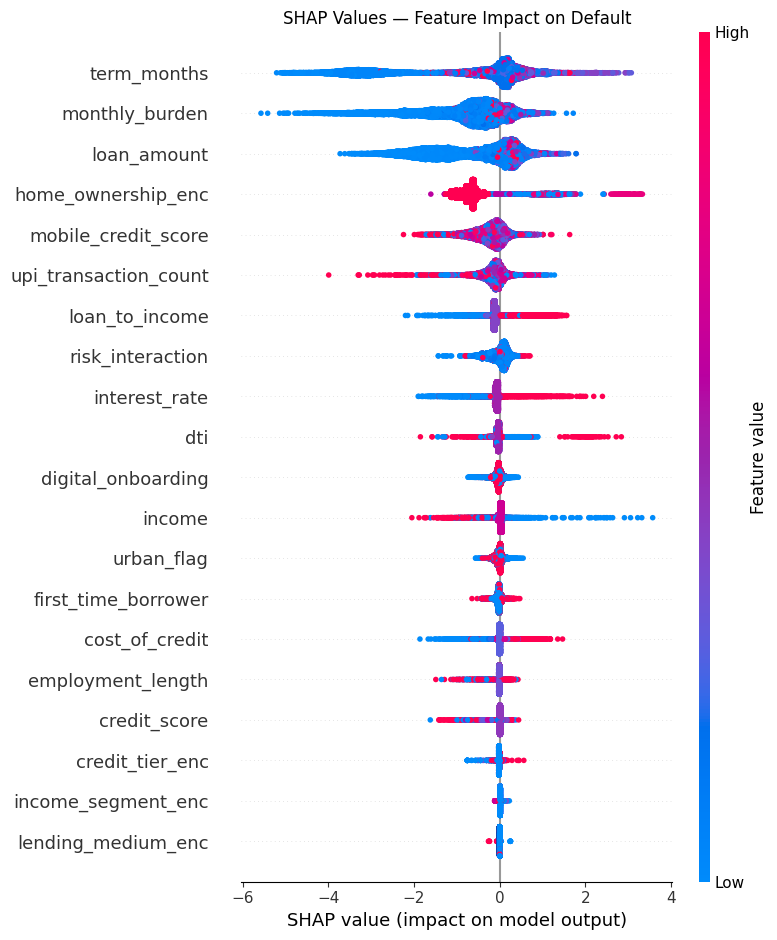

SHAP plots saved!


In [5]:
import shap

# ── Best models ──────────────────────────────────────────
best_clf = models_clf['XGBoost']    # best recall on defaults
best_risk = models_risk['XGBoost']  # best risk classification
best_reg = models_reg['XGBoost']    # best MAE

# ── SHAP on XGBoost ──────────────────────────────────────
explainer = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X_test)

# ── SHAP plots ───────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=features,
                  plot_type='bar', show=False)
plt.title('Feature Importance — Default Prediction')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.title('SHAP Values — Feature Impact on Default')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("SHAP plots saved!")

In [6]:
conn = sqlite3.connect('digital_lending.db')

# Predict on full sample
predictions_df = pd.DataFrame({
    'loan_id': df.loc[X_sample.index, 'loan_id'].values,
    'predicted_default': best_clf.predict(X_sample),
    'default_probability': best_clf.predict_proba(X_sample)[:, 1],
    'predicted_risk_tier': best_risk.predict(X_sample),
    'predicted_expected_loss': best_reg.predict(X_sample)
})

# Map risk tier back
risk_map = {0: 'Low', 1: 'Medium', 2: 'High'}
predictions_df['predicted_risk_tier'] = predictions_df['predicted_risk_tier'].map(risk_map)

predictions_df.to_sql('ml_predictions', conn, if_exists='replace', index=False)

# Save SHAP importance
shap_importance = pd.DataFrame({
    'feature': features,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

shap_importance.to_sql('shap_importance', conn, if_exists='replace', index=False)

print(f"Predictions saved: {len(predictions_df)} rows")
print(f"\nSHAP Importance:")
print(shap_importance.head(10))

conn.close()

Predictions saved: 100000 rows

SHAP Importance:
                  feature  importance
2             term_months    1.180569
8          monthly_burden    0.857953
0             loan_amount    0.851077
18     home_ownership_enc    0.778885
15    mobile_credit_score    0.301791
14  upi_transaction_count    0.194831
7          loan_to_income    0.167827
12       risk_interaction    0.151234
1           interest_rate    0.114052
4                     dti    0.069035


In [7]:
import numpy as np
import pandas as pd
import sqlite3
from scipy.optimize import minimize

conn = sqlite3.connect('digital_lending.db')
df_pred = pd.read_sql_query("""
    SELECT l.*, m.predicted_default, m.default_probability, 
           m.predicted_risk_tier, m.predicted_expected_loss
    FROM loans l
    JOIN ml_predictions m ON l.loan_id = m.loan_id
""", conn)
conn.close()

print(f"Loaded: {df_pred.shape}")

# ══════════════════════════════════════════════════════════
# OPTIMIZATION 1 — OPTIMAL APPROVAL THRESHOLD
# Find threshold that maximizes profit while keeping
# default rate below 10%
# ══════════════════════════════════════════════════════════
print("\n── Optimization 1: Approval Threshold ──")

# Business assumptions
avg_loan = df_pred['loan_amount'].mean()
avg_interest = df_pred['interest_rate'].mean() / 100
avg_term = df_pred['term_months'].mean() / 12
revenue_per_good_loan = avg_loan * avg_interest * avg_term
loss_per_default = avg_loan * 0.6  # 60% loss given default

thresholds = np.arange(0.01, 0.99, 0.01)
results = []

for threshold in thresholds:
    approved = df_pred[df_pred['default_probability'] <= threshold]
    if len(approved) == 0:
        continue
    
    actual_defaults = approved['default'].sum()
    actual_good = len(approved) - actual_defaults
    default_rate = actual_defaults / len(approved)
    
    revenue = actual_good * revenue_per_good_loan
    losses = actual_defaults * loss_per_default
    profit = revenue - losses
    approval_rate = len(approved) / len(df_pred)
    
    results.append({
        'threshold': threshold,
        'approval_rate': approval_rate,
        'default_rate': default_rate,
        'profit': profit,
        'approved_loans': len(approved)
    })

results_df = pd.DataFrame(results)

# Find optimal threshold
optimal = results_df[results_df['default_rate'] <= 0.10].sort_values('profit', ascending=False).iloc[0]
print(f"Optimal Threshold: {optimal['threshold']:.2f}")
print(f"Approval Rate: {optimal['approval_rate']:.1%}")
print(f"Default Rate: {optimal['default_rate']:.1%}")
print(f"Estimated Profit: ${optimal['profit']:,.0f}")

# ══════════════════════════════════════════════════════════
# OPTIMIZATION 2 — PRICING RECOMMENDATION ENGINE
# Recommend interest rate per risk segment
# ══════════════════════════════════════════════════════════
print("\n── Optimization 2: Pricing Engine ──")

def recommend_rate(row):
    base_rate = 8.0  # base interest rate %
    
    # Risk adjustment
    if row['predicted_risk_tier'] == 'High':
        risk_premium = 8.0
    elif row['predicted_risk_tier'] == 'Medium':
        risk_premium = 4.0
    else:
        risk_premium = 1.0
    
    # Probability adjustment
    prob_premium = row['default_probability'] * 20
    
    # Mobile credit score discount (India context)
    mobile_discount = max(0, (row['mobile_credit_score'] - 650) / 100)
    
    # UPI activity discount
    upi_discount = min(1.5, row['upi_transaction_count'] / 100)
    
    # First time borrower premium
    first_timer_premium = 2.0 if row['first_time_borrower'] == 1 else 0
    
    recommended_rate = (base_rate + risk_premium + prob_premium 
                       + first_timer_premium - mobile_discount - upi_discount)
    
    return round(np.clip(recommended_rate, 6.0, 36.0), 2)

df_pred['recommended_rate'] = df_pred.apply(recommend_rate, axis=1)

print("\nRecommended Rate by Risk Tier:")
print(df_pred.groupby('predicted_risk_tier')['recommended_rate'].agg(['mean','min','max']).round(2))

print("\nRecommended Rate by Lending Medium:")
print(df_pred.groupby('lending_medium')['recommended_rate'].mean().round(2))

# ══════════════════════════════════════════════════════════
# OPTIMIZATION 3 — PORTFOLIO HEALTH SCORING
# Score each lending medium's portfolio quality
# ══════════════════════════════════════════════════════════
print("\n── Optimization 3: Portfolio Health Score ──")

def portfolio_health_score(group):
    default_rate = group['default'].mean()
    avg_prob = group['default_probability'].mean()
    high_risk_pct = (group['predicted_risk_tier'] == 'High').mean()
    avg_mobile_score = group['mobile_credit_score'].mean()
    digital_pct = group['digital_onboarding'].mean()
    
    # Score 0-100 (higher = healthier)
    score = (
        (1 - default_rate) * 30 +        # 30% weight
        (1 - avg_prob) * 25 +             # 25% weight
        (1 - high_risk_pct) * 20 +        # 20% weight
        (avg_mobile_score / 850) * 15 +   # 15% weight
        digital_pct * 10                   # 10% weight
    ) * 100
    
    return round(score, 2)

health_scores = df_pred.groupby('lending_medium').apply(portfolio_health_score).reset_index()
health_scores.columns = ['lending_medium', 'health_score']
health_scores = health_scores.sort_values('health_score', ascending=False)
print(health_scores)

# ══════════════════════════════════════════════════════════
# OPTIMIZATION 4 — EARLY WARNING SYSTEM
# Flag loans showing stress signals
# ══════════════════════════════════════════════════════════
print("\n── Optimization 4: Early Warning Flags ──")

def early_warning(row):
    flags = []
    
    if row['default_probability'] > 0.6:
        flags.append('HIGH_DEFAULT_RISK')
    if row['dti'] > 40:
        flags.append('HIGH_DTI')
    if row['loan_to_income'] > 5:
        flags.append('LOAN_INCOME_STRESS')
    if row['mobile_credit_score'] < 550:
        flags.append('LOW_MOBILE_SCORE')
    if row['upi_transaction_count'] < 10:
        flags.append('LOW_DIGITAL_ACTIVITY')
    if row['monthly_burden'] > 1000:
        flags.append('HIGH_MONTHLY_BURDEN')
    
    if not flags:
        return 'HEALTHY'
    elif len(flags) == 1:
        return 'WATCH'
    elif len(flags) == 2:
        return 'WARNING'
    else:
        return 'CRITICAL'

df_pred['early_warning'] = df_pred.apply(early_warning, axis=1)

print("\nEarly Warning Distribution:")
print(df_pred['early_warning'].value_counts())

print("\nEarly Warning by Medium:")
print(pd.crosstab(df_pred['lending_medium'], df_pred['early_warning']))

# ── Save all optimization outputs to SQLite ──────────────
conn = sqlite3.connect('digital_lending.db')

# Threshold analysis
results_df.to_sql('threshold_analysis', conn, if_exists='replace', index=False)

# Full predictions with pricing and warnings
df_pred[['loan_id', 'lending_medium', 'default', 'default_probability',
         'predicted_risk_tier', 'predicted_expected_loss',
         'recommended_rate', 'early_warning']].to_sql(
    'optimization_output', conn, if_exists='replace', index=False
)

# Portfolio health
health_scores.to_sql('portfolio_health', conn, if_exists='replace', index=False)

conn.close()
print("\nAll optimization outputs saved to SQLite!")

Loaded: (100000, 31)

── Optimization 1: Approval Threshold ──
Optimal Threshold: 0.78
Approval Rate: 94.9%
Default Rate: 1.3%
Estimated Profit: $167,185,678

── Optimization 2: Pricing Engine ──

Recommended Rate by Risk Tier:
                      mean    min    max
predicted_risk_tier                     
High                 34.57  16.95  36.00
Low                  12.32   6.40  29.96
Medium               19.19   9.65  32.63

Recommended Rate by Lending Medium:
lending_medium
Bank            20.33
Microfinance    11.64
P2P             19.67
SME             25.97
Name: recommended_rate, dtype: float64

── Optimization 3: Portfolio Health Score ──
  lending_medium  health_score
1   Microfinance       8957.48
2            P2P       7534.34
0           Bank       7073.26
3            SME       5941.64

── Optimization 4: Early Warning Flags ──

Early Warning Distribution:
early_warning
HEALTHY     80015
WATCH       16876
WARNING      2051
CRITICAL     1058
Name: count, dtype: int64

Ea

In [8]:
conn = sqlite3.connect('digital_lending.db')
health = pd.read_sql_query("SELECT * FROM portfolio_health ORDER BY health_score DESC", conn)
conn.close()
print(health)

  lending_medium  health_score
0   Microfinance       8957.48
1            P2P       7534.34
2           Bank       7073.26
3            SME       5941.64


In [9]:
conn = sqlite3.connect('digital_lending.db')

health_scores = df_pred.groupby('lending_medium').agg(
    default_rate=('default', 'mean'),
    avg_default_prob=('default_probability', 'mean'),
    high_risk_pct=('predicted_risk_tier', lambda x: (x == 'High').mean()),
    avg_mobile_score=('mobile_credit_score', 'mean'),
    digital_pct=('digital_onboarding', 'mean')
).reset_index()

# Score 0-100
health_scores['health_score'] = (
    (1 - health_scores['default_rate']) * 30 +
    (1 - health_scores['avg_default_prob']) * 25 +
    (1 - health_scores['high_risk_pct']) * 20 +
    (health_scores['avg_mobile_score'] / 850) * 15 +
    health_scores['digital_pct'] * 10
) * 100

health_scores['health_score'] = health_scores['health_score'].round(2)
health_scores = health_scores.sort_values('health_score', ascending=False)

health_scores.to_sql('portfolio_health', conn, if_exists='replace', index=False)
print(health_scores[['lending_medium', 'health_score', 'default_rate', 'high_risk_pct']])

conn.close()

  lending_medium  health_score  default_rate  high_risk_pct
1   Microfinance       8957.48      0.015840       0.002016
2            P2P       7534.34      0.144447       0.056229
0           Bank       7073.26      0.222666       0.177051
3            SME       5941.64      0.333448       0.272759


In [10]:
conn = sqlite3.connect('digital_lending.db')

health_scores = df_pred.groupby('lending_medium').agg(
    default_rate=('default', 'mean'),
    avg_default_prob=('default_probability', 'mean'),
    high_risk_pct=('predicted_risk_tier', lambda x: (x == 'High').mean()),
    avg_mobile_score=('mobile_credit_score', 'mean'),
    digital_pct=('digital_onboarding', 'mean')
).reset_index()

# Debug — check values
print("Raw values:")
print(health_scores)

# Score 0-100 — remove the * 100
health_scores['health_score'] = round(
    (1 - health_scores['default_rate']) * 30 +
    (1 - health_scores['avg_default_prob']) * 25 +
    (1 - health_scores['high_risk_pct']) * 20 +
    (health_scores['avg_mobile_score'] / 850) * 15 +
    health_scores['digital_pct'] * 10
, 2)

health_scores = health_scores.sort_values('health_score', ascending=False)
print("\nHealth Scores:")
print(health_scores[['lending_medium', 'health_score']])

health_scores.to_sql('portfolio_health', conn, if_exists='replace', index=False)
conn.close()

Raw values:
  lending_medium  default_rate  avg_default_prob  high_risk_pct  \
0           Bank      0.222666          0.503522       0.177051   
1   Microfinance      0.015840          0.134210       0.002016   
2            P2P      0.144447          0.506125       0.056229   
3            SME      0.333448          0.742092       0.272759   

   avg_mobile_score  digital_pct  
0        650.308441     0.706560  
1        649.286207     0.698761  
2        648.874608     0.700378  
3        649.307153     0.696897  

Health Scores:
  lending_medium  health_score
1   Microfinance         89.57
2            P2P         75.34
0           Bank         70.73
3            SME         59.42


In [11]:
conn = sqlite3.connect('digital_lending.db')
health = pd.read_sql_query("SELECT * FROM portfolio_health", conn)
conn.close()
print(health.columns.tolist())
print(health.head())

['lending_medium', 'default_rate', 'avg_default_prob', 'high_risk_pct', 'avg_mobile_score', 'digital_pct', 'health_score']
  lending_medium  default_rate  avg_default_prob  high_risk_pct  \
0   Microfinance      0.015840          0.134210       0.002016   
1            P2P      0.144447          0.506125       0.056229   
2           Bank      0.222666          0.503522       0.177051   
3            SME      0.333448          0.742092       0.272759   

   avg_mobile_score  digital_pct  health_score  
0        649.286207     0.698761         89.57  
1        648.874608     0.700378         75.34  
2        650.308441     0.706560         70.73  
3        649.307153     0.696897         59.42  


In [12]:
conn = sqlite3.connect('digital_lending.db')
loans = pd.read_sql_query("SELECT * FROM loans LIMIT 5", conn)
opt = pd.read_sql_query("SELECT * FROM optimization_output LIMIT 5", conn)
conn.close()

print("Loans columns:", loans.columns.tolist())
print("\nOpt columns:", opt.columns.tolist())

Loans columns: ['loan_amount', 'interest_rate', 'term_months', 'income', 'dti', 'credit_score', 'employment_length', 'home_ownership', 'lending_medium', 'default', 'loan_to_income', 'monthly_burden', 'high_dti_flag', 'long_term_flag', 'cost_of_credit', 'loan_size', 'credit_tier', 'income_segment', 'risk_interaction', 'digital_onboarding', 'upi_transaction_count', 'mobile_credit_score', 'first_time_borrower', 'urban_flag', 'risk_tier', 'expected_loss', 'loan_id']

Opt columns: ['loan_id', 'lending_medium', 'default', 'default_probability', 'predicted_risk_tier', 'predicted_expected_loss', 'recommended_rate', 'early_warning']


In [13]:
conn = sqlite3.connect('digital_lending.db')

loans = pd.read_sql_query("SELECT * FROM loans", conn)
opt = pd.read_sql_query("SELECT * FROM optimization_output", conn)
health = pd.read_sql_query("SELECT * FROM portfolio_health", conn)

conn.close()

# Drop duplicate columns from opt before merging
opt_clean = opt.drop(columns=['lending_medium', 'default'])

# Merge
master = loans.merge(opt_clean, on='loan_id', how='left')
master = master.merge(health[['lending_medium', 'health_score']], 
                      on='lending_medium', how='left')

# Save back
conn = sqlite3.connect('digital_lending.db')
master.to_sql('master_view', conn, if_exists='replace', index=False)
print(f"Master view: {master.shape}")
print(master.columns.tolist())
conn.close()

Master view: (765140, 33)
['loan_amount', 'interest_rate', 'term_months', 'income', 'dti', 'credit_score', 'employment_length', 'home_ownership', 'lending_medium', 'default', 'loan_to_income', 'monthly_burden', 'high_dti_flag', 'long_term_flag', 'cost_of_credit', 'loan_size', 'credit_tier', 'income_segment', 'risk_interaction', 'digital_onboarding', 'upi_transaction_count', 'mobile_credit_score', 'first_time_borrower', 'urban_flag', 'risk_tier', 'expected_loss', 'loan_id', 'default_probability', 'predicted_risk_tier', 'predicted_expected_loss', 'recommended_rate', 'early_warning', 'health_score']


K=2 done
K=3 done
K=4 done
K=5 done
K=6 done
K=7 done
K=8 done
K=9 done


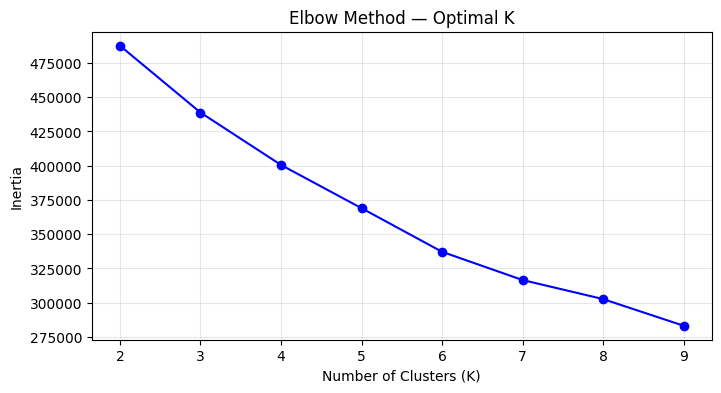

Elbow plot saved!


In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ── Features for clustering ──────────────────────────────
cluster_features = [
    'loan_amount', 'interest_rate', 'term_months',
    'income', 'dti', 'loan_to_income', 'monthly_burden',
    'mobile_credit_score', 'upi_transaction_count',
    'digital_onboarding', 'first_time_borrower', 'urban_flag'
]

# Sample for speed
sample = master[cluster_features].dropna().sample(50000, random_state=42)

# Scale
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(sample)

# ── Find optimal K (Elbow Method) ────────────────────────
inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    print(f"K={k} done")

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.grid(True, alpha=0.3)
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Elbow plot saved!")

In [15]:
# ── Train final K-Means with K=5 ─────────────────────────
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
km_final.fit(X_cluster)

sample_with_clusters = master[cluster_features].dropna().sample(50000, random_state=42).copy()
sample_with_clusters['cluster'] = km_final.labels_

# ── Profile each cluster ─────────────────────────────────
cluster_profile = sample_with_clusters.groupby('cluster').agg(
    loan_amount=('loan_amount', 'mean'),
    income=('income', 'mean'),
    dti=('dti', 'mean'),
    interest_rate=('interest_rate', 'mean'),
    term_months=('term_months', 'mean'),
    mobile_credit_score=('mobile_credit_score', 'mean'),
    upi_transactions=('upi_transaction_count', 'mean'),
    digital_pct=('digital_onboarding', 'mean'),
    urban_pct=('urban_flag', 'mean'),
    first_timer_pct=('first_time_borrower', 'mean'),
    size=('loan_amount', 'count')
).round(2)

print("── Cluster Profiles ──")
print(cluster_profile)

# ── Merge default rate into profile ──────────────────────
master_sample = master.dropna(subset=cluster_features).sample(50000, random_state=42).copy()
master_sample['cluster'] = km_final.labels_

default_by_cluster = master_sample.groupby('cluster')['default'].mean().round(3)
cluster_profile['default_rate'] = default_by_cluster
print("\n── Default Rate by Cluster ──")
print(cluster_profile[['size', 'loan_amount', 'income', 'dti', 'default_rate']])

── Cluster Profiles ──
         loan_amount    income    dti  interest_rate  term_months  \
cluster                                                             
0            1852.86  59572.70  11.04          10.74        15.37   
1          955139.75  49627.89   0.32           7.91       127.40   
2            1806.02  59426.24  11.03          10.74        15.14   
3            1819.42  59512.36  11.09          10.74        15.24   
4          256556.26  84154.60   0.32           7.98       141.21   

         mobile_credit_score  upi_transactions  digital_pct  urban_pct  \
cluster                                                                  
0                     649.25             45.01         0.70       0.65   
1                     659.75             45.09         0.64       0.67   
2                     649.46             45.03         0.70       0.00   
3                     649.84             44.98         0.70       1.00   
4                     647.31             45.30   

In [16]:
segment_names = {
    0: 'First-Time Micro Borrowers',
    1: 'High-Value Stressed',
    2: 'Rural Micro Borrowers',
    3: 'Urban Established',
    4: 'High-Income Large Borrowers'
}

master_sample['segment'] = master_sample['cluster'].map(segment_names)

# Assign segments to full dataset using nearest centroid
X_full = scaler_cluster.transform(
    master[cluster_features].fillna(master[cluster_features].median())
)
master['cluster'] = km_final.predict(X_full)
master['segment'] = master['cluster'].map(segment_names)

# Segment summary
segment_summary = master.groupby('segment').agg(
    total_loans=('default', 'count'),
    default_rate=('default', 'mean'),
    avg_loan=('loan_amount', 'mean'),
    avg_income=('income', 'mean'),
    avg_recommended_rate=('recommended_rate', 'mean'),
    high_risk_pct=('predicted_risk_tier', lambda x: (x == 'High').mean() if x.notna().any() else 0)
).round(3).reset_index()

print("── Segment Summary ──")
print(segment_summary)

# Save to SQLite
conn = sqlite3.connect('digital_lending.db')
master.to_sql('master_view', conn, if_exists='replace', index=False)
segment_summary.to_sql('segment_summary', conn, if_exists='replace', index=False)
conn.close()

print("\nSegments saved!")

── Segment Summary ──
                       segment  total_loans  default_rate    avg_loan  \
0   First-Time Micro Borrowers       260523         0.032    1843.252   
1  High-Income Large Borrowers        18943         0.320  260130.413   
2          High-Value Stressed         2326         0.352  972368.918   
3        Rural Micro Borrowers       169465         0.032    1839.548   
4            Urban Established       313883         0.031    1827.045   

   avg_income  avg_recommended_rate  high_risk_pct  
0   59488.435                13.788          0.002  
1   83783.434                25.704          0.033  
2   54498.747                26.080          0.044  
3   59480.423                11.645          0.002  
4   59494.875                11.791          0.002  

Segments saved!


In [17]:
# Save models for API
import pickle
import torch

# Save XGBoost models
with open('models/xgb_default.pkl', 'wb') as f:
    pickle.dump(best_clf, f)

with open('models/xgb_risk.pkl', 'wb') as f:
    pickle.dump(best_risk, f)

with open('models/xgb_loss.pkl', 'wb') as f:
    pickle.dump(best_reg, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('models/kmeans.pkl', 'wb') as f:
    pickle.dump(km_final, f)

with open('models/cluster_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_cluster, f)

print("All models saved!")

All models saved!
